In [71]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost plotly

In [72]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [73]:
import pandas as pd

matches = pd.read_csv('/content/matches.csv')
deliveries = pd.read_csv('/content/deliveries.csv')

In [74]:
print(matches.shape)
print(deliveries.shape)

(1095, 20)
(260920, 17)


In [75]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [76]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [77]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [78]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [79]:
matches['team1'].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [80]:
teams = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

matches.replace(teams, inplace=True)
deliveries.replace(teams, inplace=True)

In [81]:
valid_teams = [
    'Mumbai Indians',
    'Chennai Super Kings',
    'Royal Challengers Bengaluru',
    'Kolkata Knight Riders',
    'Sunrisers Hyderabad',
    'Rajasthan Royals',
    'Delhi Capitals',
    'Punjab Kings'
]

In [82]:
matches = matches[
    matches['team1'].isin(valid_teams) &
    matches['team2'].isin(valid_teams)
]

In [83]:
matches = matches[matches['method'].isna()]

In [84]:
matches.shape

(880, 20)

In [85]:
deliveries = deliveries.merge(
    matches[['id', 'winner']],
    left_on='match_id',
    right_on='id'
)

In [86]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,winner
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,335982,Kolkata Knight Riders
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,Kolkata Knight Riders
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,335982,Kolkata Knight Riders
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,Kolkata Knight Riders
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,Kolkata Knight Riders


In [87]:
total_score_df = deliveries.groupby(['match_id', 'inning']).sum()['total_runs'].reset_index()

In [88]:
total_score_df = total_score_df[total_score_df['inning'] == 1]

In [89]:
total_score_df['total_runs_x'] = total_score_df['total_runs']

In [90]:
total_score_df.head()

,match_id,inning,total_runs,total_runs_x
0,335982,1,222,222
2,335983,1,240,240
4,335984,1,129,129
6,335985,1,165,165
8,335986,1,110,110


In [91]:
match_df = matches.merge(
    total_score_df[['match_id', 'total_runs_x']],
    left_on='id',
    right_on='match_id'
)

In [92]:
match_df = match_df[
    match_df['team1'].isin(valid_teams) &
    match_df['team2'].isin(valid_teams)
]

In [93]:
match_df = match_df[
    ['match_id', 'city', 'winner', 'total_runs_x',
     'team1', 'team2']
]

In [94]:
match_df.head()

,match_id,city,winner,total_runs_x,team1,team2
0,335982,Bangalore,Kolkata Knight Riders,222,Royal Challengers Bengaluru,Kolkata Knight Riders
1,335983,Chandigarh,Chennai Super Kings,240,Punjab Kings,Chennai Super Kings
2,335984,Delhi,Delhi Capitals,129,Delhi Capitals,Rajasthan Royals
3,335985,Mumbai,Royal Challengers Bengaluru,165,Mumbai Indians,Royal Challengers Bengaluru
4,335986,Kolkata,Kolkata Knight Riders,110,Kolkata Knight Riders,Sunrisers Hyderabad


In [95]:
match_df.head()

,match_id,city,winner,total_runs_x,team1,team2
0,335982,Bangalore,Kolkata Knight Riders,222,Royal Challengers Bengaluru,Kolkata Knight Riders
1,335983,Chandigarh,Chennai Super Kings,240,Punjab Kings,Chennai Super Kings
2,335984,Delhi,Delhi Capitals,129,Delhi Capitals,Rajasthan Royals
3,335985,Mumbai,Royal Challengers Bengaluru,165,Mumbai Indians,Royal Challengers Bengaluru
4,335986,Kolkata,Kolkata Knight Riders,110,Kolkata Knight Riders,Sunrisers Hyderabad


In [96]:
delivery_df = match_df.merge(deliveries, on='match_id')

In [97]:
delivery_df = delivery_df[delivery_df['inning'] == 2]

In [98]:
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs'].cumsum()

In [99]:
delivery_df['runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']

In [100]:
delivery_df['balls_left'] = 120 - (
    delivery_df['over'] * 6 + delivery_df['ball']
)

In [101]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].fillna("0")

In [102]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].apply(
    lambda x: 0 if x == "0" else 1
)

In [103]:
wickets = delivery_df.groupby('match_id')['player_dismissed'].cumsum().values

In [104]:
delivery_df['wickets_left'] = 10 - wickets

In [105]:
delivery_df['crr'] = (
    delivery_df['current_score'] * 6
) / (
    120 - delivery_df['balls_left']
)

In [106]:
delivery_df['rrr'] = (
    delivery_df['runs_left'] * 6
) / delivery_df['balls_left']

In [107]:
def result(row):
    return 1 if row['batting_team'] == row['winner_y'] else 0

delivery_df['result'] = delivery_df.apply(result, axis=1)

In [108]:
final_df = delivery_df[
    ['batting_team',
     'bowling_team',
     'city',
     'runs_left',
     'balls_left',
     'wickets_left',
     'total_runs_x',
     'crr',
     'rrr',
     'result']
]

In [109]:
final_df = final_df.dropna()

In [110]:
final_df = final_df[final_df['balls_left'] != 0]

In [111]:
final_df.head()

,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,total_runs_x,crr,rrr,result
124,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,221,119,10,222,6.0,11.142857,0
125,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,220,118,10,222,6.0,11.186441,0
126,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,220,117,10,222,4.0,11.282051,0
127,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,219,116,10,222,4.5,11.327586,0
128,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,218,115,10,222,4.8,11.373913,0


In [112]:
X = final_df.drop('result', axis=1)
y = final_df['result']

In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [114]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [115]:
trf = ColumnTransformer([
    ('trf', OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
     ['batting_team', 'bowling_team', 'city'])
],
remainder='passthrough')

In [116]:
from sklearn.linear_model import LogisticRegression

In [117]:
pipe = Pipeline(steps=[
    ('step1', trf),
    ('step2', LogisticRegression(solver='liblinear'))
])

In [118]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2', LogisticRegression(solver='liblinear'))])

In [119]:
y_pred = pipe.predict(X_test)

In [120]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8068443051201671

In [121]:
pipe.predict_proba(X_test)[10]

array([0.61736985, 0.38263015])

In [122]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline(steps=[
    ('step1', trf),
    ('step2', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [123]:
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2', RandomForestClassifier(random_state=42))])

In [124]:
y_pred_rf = pipe_rf.predict(X_test)

In [125]:
accuracy_score(y_test, y_pred_rf)

0.9991640543364682

In [126]:
from xgboost import XGBClassifier

In [127]:
pipe_xgb = Pipeline(steps=[
    ('step1', trf),
    ('step2', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ))
])

In [128]:
pipe_xgb.fit(X_train, y_train)

Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [129]:
y_pred_xgb = pipe_xgb.predict(X_test)

In [130]:
accuracy_score(y_test, y_pred_xgb)

0.9452455590386625

In [131]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']

accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.806844
1,Random Forest,0.999164
2,XGBoost,0.945246


In [132]:
final_df = final_df.sample(final_df.shape[0])

In [133]:
final_df = final_df.drop_duplicates()

In [134]:
final_df = final_df[final_df['balls_left'] < 100]

In [135]:
X = final_df.drop('result', axis=1)
y = final_df['result']

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

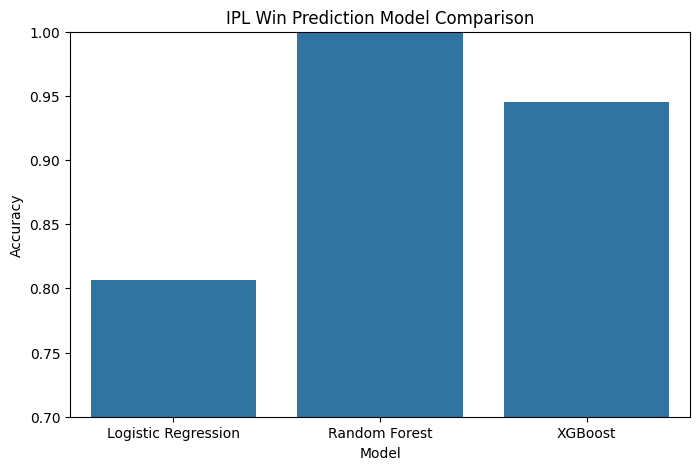

In [137]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("IPL Win Prediction Model Comparison")

plt.ylim(0.7, 1)

plt.show()

In [138]:
final_df = final_df.sample(final_df.shape[0], random_state=42)

In [139]:
final_df = final_df.drop_duplicates()

In [140]:
final_df = final_df[final_df['balls_left'] < 100]

In [141]:
final_df = final_df[final_df['balls_left'] < 100]

In [142]:
X = final_df.drop('result', axis=1)
y = final_df['result']

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [144]:
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

log_acc = accuracy_score(y_test, y_pred)

print(log_acc)

0.8240912879030707


In [145]:
pipe_rf.fit(X_train, y_train)

y_pred_rf = pipe_rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print(rf_acc)

0.9990383998974294


In [146]:
pipe_xgb.fit(X_train, y_train)

y_pred_xgb = pipe_xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(xgb_acc)

0.9477530610936599


In [147]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        log_acc,
        rf_acc,
        xgb_acc
    ]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.824091
1,Random Forest,0.999038
2,XGBoost,0.947753


In [148]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

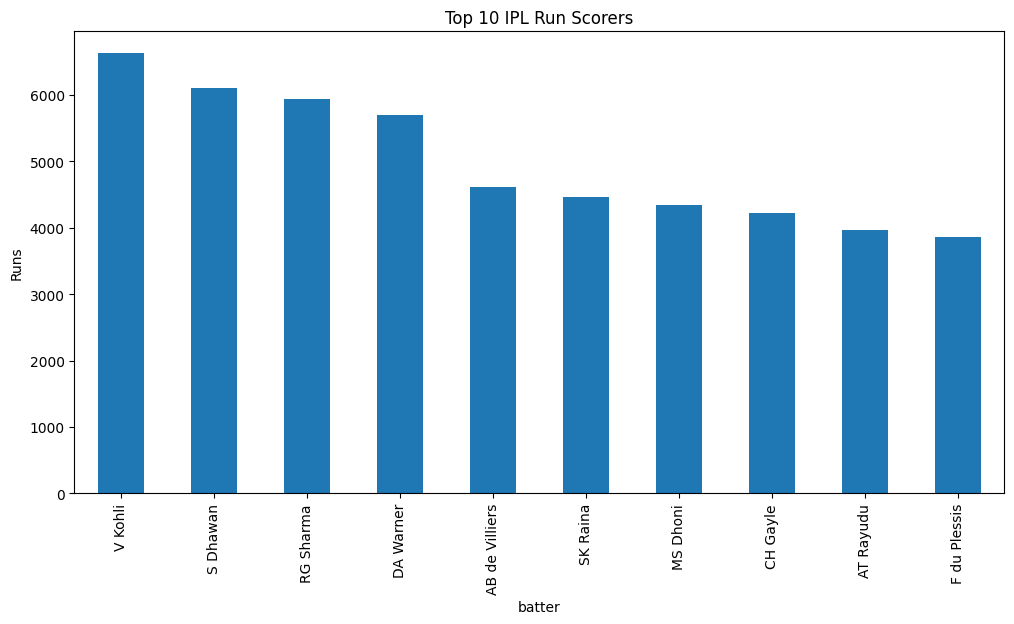

In [149]:
plt.figure(figsize=(12,6))

top_batsmen.plot(kind='bar')

plt.title("Top 10 IPL Run Scorers")

plt.ylabel("Runs")

plt.show()

In [150]:
batsman_stats = deliveries.groupby('batter').agg({
    'batsman_runs': 'sum',
    'ball': 'count'
}).reset_index()

In [151]:
batsman_stats['strike_rate'] = (
    batsman_stats['batsman_runs'] /
    batsman_stats['ball']
) * 100

In [152]:
batsman_stats = batsman_stats[
    batsman_stats['batsman_runs'] > 1000
]

In [153]:
top_sr = batsman_stats.sort_values(
    by='strike_rate',
    ascending=False
).head(10)

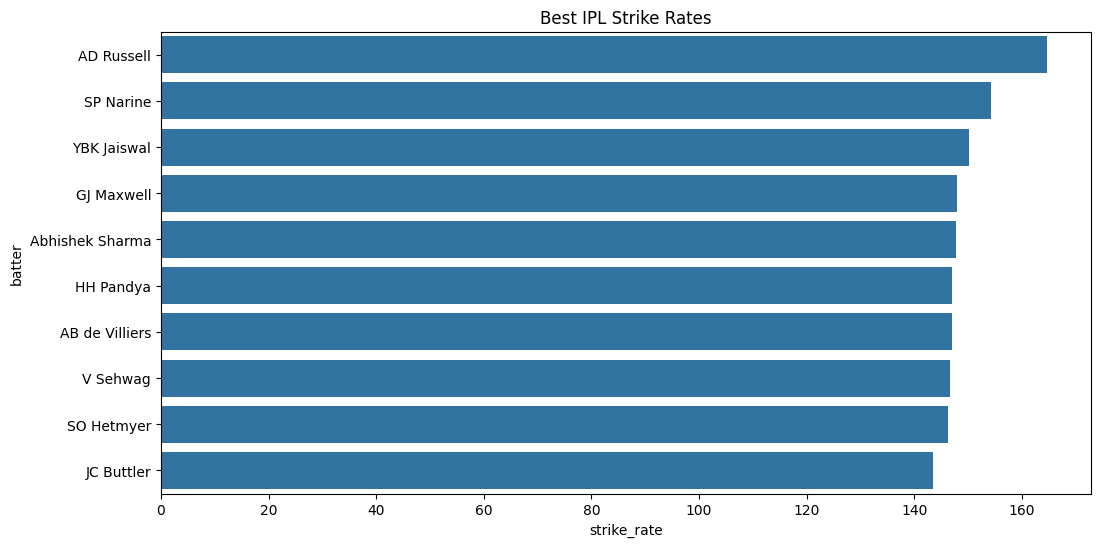

In [154]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='strike_rate',
    y='batter',
    data=top_sr
)

plt.title("Best IPL Strike Rates")

plt.show()

In [155]:
venue_scores = matches.groupby('city')['target_runs'].mean().sort_values(ascending=False)

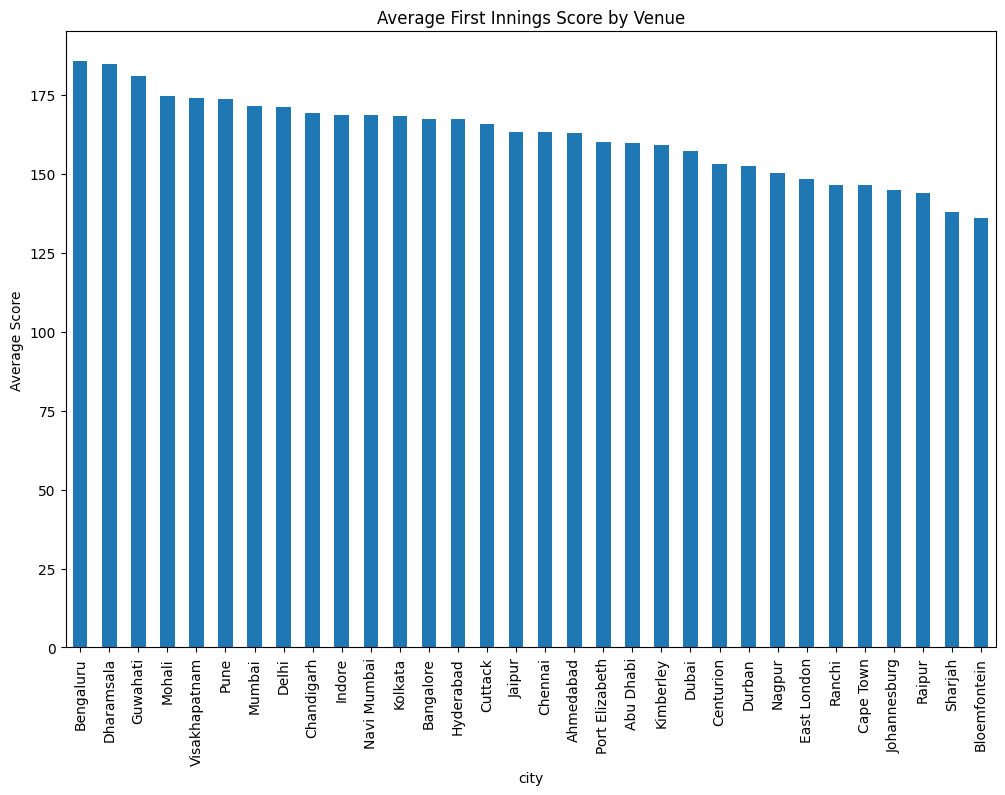

In [156]:
plt.figure(figsize=(12,8))

venue_scores.plot(kind='bar')

plt.title("Average First Innings Score by Venue")

plt.ylabel("Average Score")

plt.show()

In [157]:
team_wins = matches['winner'].value_counts().head(10)

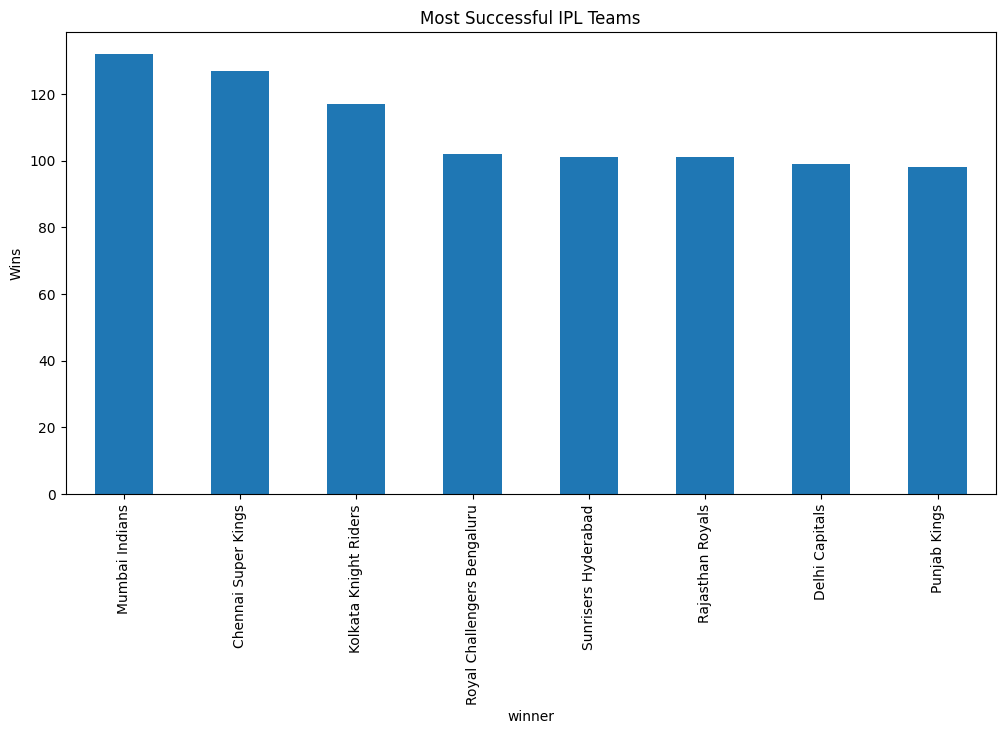

In [158]:
plt.figure(figsize=(12,6))

team_wins.plot(kind='bar')

plt.title("Most Successful IPL Teams")

plt.ylabel("Wins")

plt.show()

In [159]:
toss_win_match_win = matches[
    matches['toss_winner'] == matches['winner']
]

In [160]:
percentage = (
    len(toss_win_match_win) / len(matches)
) * 100

print("Toss Winner Also Won Match:", percentage)

Toss Winner Also Won Match: 50.45454545454545


In [161]:
csk_mi = matches[
    (
        (matches['team1'] == 'Chennai Super Kings') &
        (matches['team2'] == 'Mumbai Indians')
    ) |
    (
        (matches['team1'] == 'Mumbai Indians') &
        (matches['team2'] == 'Chennai Super Kings')
    )
]

In [162]:
csk_mi['winner'].value_counts()

,count
winner,
Mumbai Indians,20
Chennai Super Kings,17


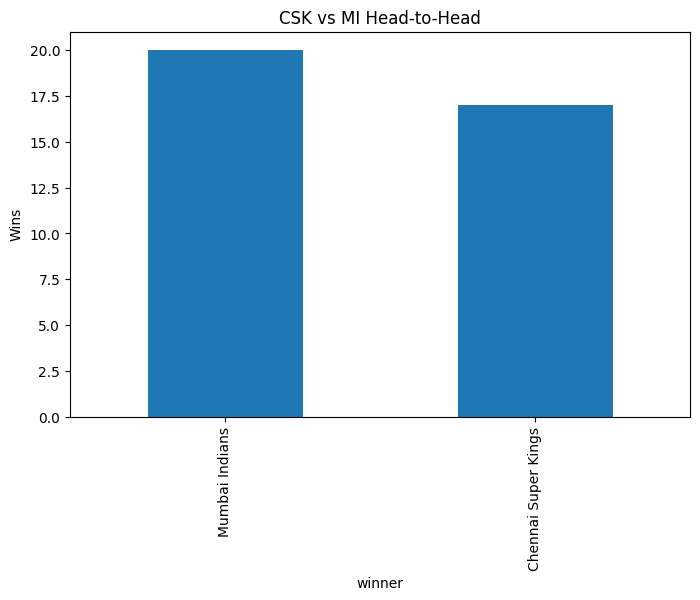

In [163]:
plt.figure(figsize=(8,5))

csk_mi['winner'].value_counts().plot(kind='bar')

plt.title("CSK vs MI Head-to-Head")

plt.ylabel("Wins")

plt.show()

In [164]:
top_bowlers = deliveries[deliveries['is_wicket'] == 1]

In [165]:
top_bowlers = top_bowlers['bowler'].value_counts().head(10)

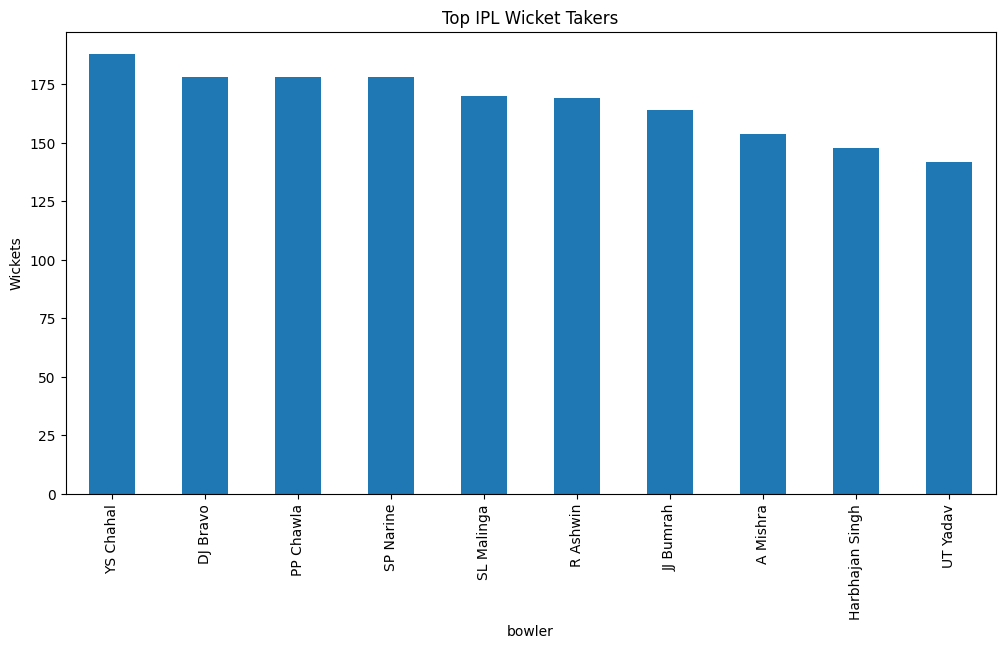

In [166]:
plt.figure(figsize=(12,6))

top_bowlers.plot(kind='bar')

plt.title("Top IPL Wicket Takers")

plt.ylabel("Wickets")

plt.show()

In [167]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 45.4 MB/s eta 0:00:00


In [168]:
import pickle

pickle.dump(pipe, open('pipe.pkl', 'wb'))

In [169]:
teams = final_df['batting_team'].unique()

pickle.dump(teams, open('teams.pkl', 'wb'))

In [170]:
cities = final_df['city'].unique()

pickle.dump(cities, open('cities.pkl', 'wb'))

In [171]:
%%writefile app.py

Writing app.py


In [203]:
%%writefile app.py

import streamlit as st
import pickle
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# LOAD FILES
# ==========================================

pipe = pickle.load(open('pipe.pkl', 'rb'))

teams = pickle.load(open('teams.pkl', 'rb'))

cities = pickle.load(open('cities.pkl', 'rb'))

matches = pd.read_csv('matches.csv')

deliveries = pd.read_csv('deliveries.csv')

# ==========================================
# PAGE CONFIG
# ==========================================

st.set_page_config(
    page_title="IPL Sports Analytics",
    page_icon="🏏",
    layout="wide"
)

# ==========================================
# SIDEBAR
# ==========================================

st.sidebar.title("🏏 IPL Sports Analytics")

st.sidebar.markdown("""
### Features
- Live Win Prediction
- Player Analytics
- Venue Analysis
- Team Statistics
- ML-Based Predictions
""")

st.sidebar.write("---")

st.sidebar.info(
    "Built using Machine Learning, "
    "Streamlit & IPL Ball-by-Ball Data"
)

# ==========================================
# TITLE
# ==========================================

st.title("🏏 IPL Sports Analytics Dashboard")

st.markdown(
    "## Machine Learning Based IPL Match Prediction & Analytics Platform"
)

st.write("---")

# ==========================================
# TABS
# ==========================================

tab1, tab2, tab3, tab4 = st.tabs([
    "🏏 Live Predictor",
    "🏆 Top Batsmen",
    "🎯 Top Bowlers",
    "🏟 Venue Analysis"
])

# ==========================================
# TAB 1 — LIVE PREDICTOR
# ==========================================

with tab1:

    st.header("Live IPL Win Predictor")

    col1, col2, col3 = st.columns(3)

    with col1:

        batting_team = st.selectbox(
            'Select Batting Team',
            sorted(teams)
        )

    available_bowling_teams = [
        team for team in teams
        if team != batting_team
    ]

    with col2:

        bowling_team = st.selectbox(
            'Select Bowling Team',
            sorted(available_bowling_teams)
        )

    with col3:

        city = st.selectbox(
            'Select Match City',
            sorted(cities)
        )

    st.write("---")

    col4, col5 = st.columns(2)

    with col4:

        target = st.number_input(
            'Target Score',
            min_value=1,
            value=180
        )

    with col5:

        score = st.number_input(
            'Current Score',
            min_value=0,
            value=50
        )

    col6, col7 = st.columns(2)

    with col6:

        overs = st.number_input(
            'Overs Completed',
            min_value=0.1,
            max_value=20.0,
            value=5.0,
            step=0.1
        )

    with col7:

        wickets = st.number_input(
            'Wickets Lost',
            min_value=0,
            max_value=10,
            value=2
        )

    if st.button('Predict Probability'):

        runs_left = target - score

        balls_left = int(120 - (overs * 6))

        wickets_left = 10 - wickets

        crr = score / overs if overs > 0 else 0

        rrr = (
            (runs_left * 6) / balls_left
            if balls_left > 0 else 0
        )

        input_df = pd.DataFrame({
            'batting_team': [batting_team],
            'bowling_team': [bowling_team],
            'city': [city],
            'runs_left': [runs_left],
            'balls_left': [balls_left],
            'wickets_left': [wickets_left],
            'total_runs_x': [target],
            'crr': [crr],
            'rrr': [rrr]
        })

        result = pipe.predict_proba(input_df)

        loss = result[0][0]

        win = result[0][1]

        st.info(
            f"{batting_team} need "
            f"{runs_left} runs in "
            f"{balls_left} balls with "
            f"{wickets_left} wickets remaining."
        )

        col8, col9 = st.columns(2)

        with col8:

            st.metric(
                label=f"{batting_team} Win %",
                value=f"{round(win * 100)}%"
            )

        with col9:

            st.metric(
                label=f"{bowling_team} Win %",
                value=f"{round(loss * 100)}%"
            )

        st.progress(int(win * 100))

# ==========================================
# TAB 2 — TOP BATSMEN
# ==========================================

with tab2:

    st.header("Top IPL Run Scorers")

    top_batsmen = deliveries.groupby(
        'batter'
    )['batsman_runs'].sum().sort_values(
        ascending=False
    ).head(10)

    fig, ax = plt.subplots(figsize=(10,5))

    top_batsmen.plot(
        kind='bar',
        ax=ax
    )

    ax.set_ylabel("Runs")

    st.pyplot(fig)

# ==========================================
# TAB 3 — TOP BOWLERS
# ==========================================

with tab3:

    st.header("Top IPL Wicket Takers")

    top_bowlers = deliveries[
        deliveries['is_wicket'] == 1
    ]['bowler'].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10,5))

    top_bowlers.plot(
        kind='bar',
        ax=ax
    )

    ax.set_ylabel("Wickets")

    st.pyplot(fig)

# ==========================================
# TAB 4 — VENUE ANALYSIS
# ==========================================

with tab4:

    st.header("Average First Innings Score by Venue")

    venue_scores = matches.groupby(
        'city'
    )['target_runs'].mean().sort_values(
        ascending=False
    ).head(15)

    fig, ax = plt.subplots(figsize=(12,6))

    venue_scores.plot(
        kind='bar',
        ax=ax
    )

    ax.set_ylabel("Average Score")

    st.pyplot(fig)

# ==========================================
# FOOTER
# ==========================================

st.write("---")

st.caption(
    "Built using Python, Machine Learning, "
    "Streamlit & IPL Ball-by-Ball Dataset"
)

Overwriting app.py


In [188]:
!ls

app.py	    deliveries.csv  pipe.pkl	 teams.pkl
cities.pkl  matches.csv     sample_data


In [204]:
!pkill -f streamlit

In [179]:
!ngrok config add-authtoken 2zaEtOdjoIoNuuqdHv5zCi0vIyX_4Ld74r1RNEm828XUTH82t

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [206]:
!streamlit run app.py &



2026-05-06 07:39:27.387 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.73.166.0:8501

  Stopping...


In [205]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://3ebb-34-73-166-0.ngrok-free.app" -> "http://localhost:8501"


In [184]:
!ps -ef | grep streamlit

root       14418    7208  0 07:28 ?        00:00:00 /bin/bash -c ps -ef | grep streamlit
root       14420   14418  0 07:28 ?        00:00:00 grep streamlit


In [185]:
!tail -50 nohup.out

tail: cannot open 'nohup.out' for reading: No such file or directory


In [186]:
!streamlit run app.py



2026-05-06 07:28:55.882 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.73.166.0:8501

  Stopping...
  Stopping...


In [207]:
batter_stats = deliveries.groupby('batter').agg({
    'batsman_runs': 'sum',
    'ball': 'count'
}).reset_index()

In [208]:
batter_stats.columns = [
    'batter',
    'runs',
    'balls'
]

In [209]:
batter_stats['strike_rate'] = (
    batter_stats['runs'] /
    batter_stats['balls']
) * 100

In [210]:
batter_stats = batter_stats[
    batter_stats['runs'] > 500
]

In [211]:
from sklearn.cluster import KMeans

In [212]:
X_cluster = batter_stats[
    ['runs', 'strike_rate']
]

In [213]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

In [214]:
batter_stats['cluster'] = kmeans.fit_predict(X_cluster)

In [215]:
batter_stats.head()

,batter,runs,balls,strike_rate,cluster
15,A Symonds,955,763,125.163827,1
26,AB de Villiers,4616,3141,146.959567,0
28,AC Gilchrist,2010,1486,135.262450,3
34,AD Russell,2255,1370,164.598540,3
38,AJ Finch,900,814,110.565111,1


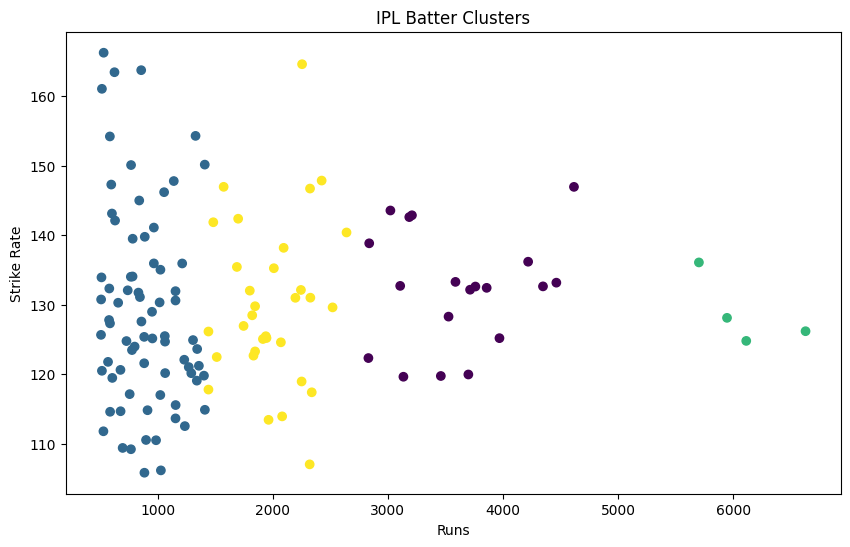

In [216]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    batter_stats['runs'],
    batter_stats['strike_rate'],
    c=batter_stats['cluster']
)

plt.xlabel("Runs")

plt.ylabel("Strike Rate")

plt.title("IPL Batter Clusters")

plt.show()

In [217]:
season_df = deliveries.merge(
    matches[['id', 'season']],
    left_on='match_id',
    right_on='id'
)

In [218]:
season_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id_x,winner,id_y,season
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,1,legbyes,0,NaN,NaN,NaN,335982,Kolkata Knight Riders,335982,2007/08
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,0,NaN,0,NaN,NaN,NaN,335982,Kolkata Knight Riders,335982,2007/08
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,1,wides,0,NaN,NaN,NaN,335982,Kolkata Knight Riders,335982,2007/08
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,0,NaN,0,NaN,NaN,NaN,335982,Kolkata Knight Riders,335982,2007/08
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,0,NaN,0,NaN,NaN,NaN,335982,Kolkata Knight Riders,335982,2007/08


In [219]:
virat = season_df[
    season_df['batter'] == 'V Kohli'
]

In [220]:
virat_runs = virat.groupby(
    'season'
)['batsman_runs'].sum()

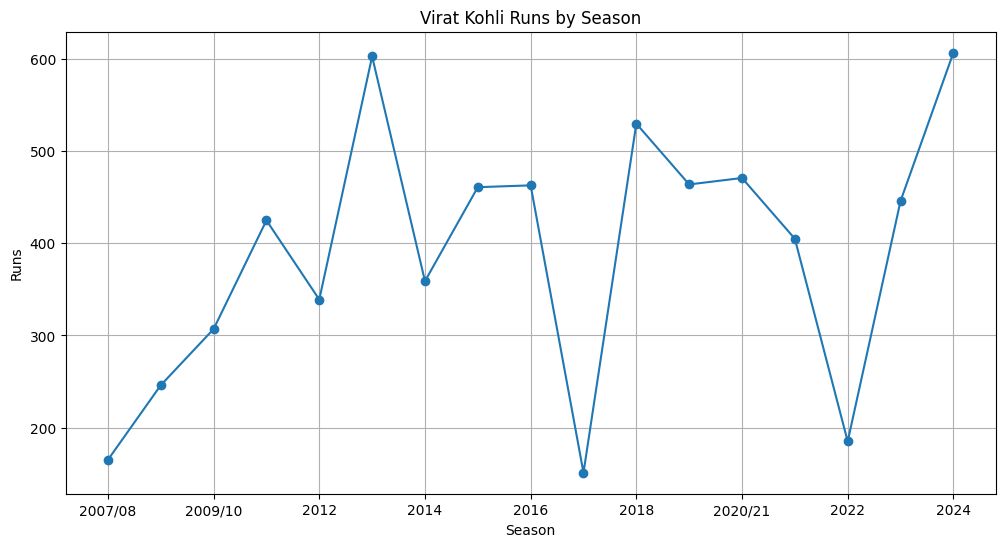

In [221]:
plt.figure(figsize=(12,6))

virat_runs.plot(
    kind='line',
    marker='o'
)

plt.title("Virat Kohli Runs by Season")

plt.ylabel("Runs")

plt.xlabel("Season")

plt.grid(True)

plt.show()

In [222]:
virat_stats = virat.groupby('season').agg({
    'batsman_runs': 'sum',
    'ball': 'count'
})

In [223]:
virat_stats['strike_rate'] = (
    virat_stats['batsman_runs'] /
    virat_stats['ball']
) * 100

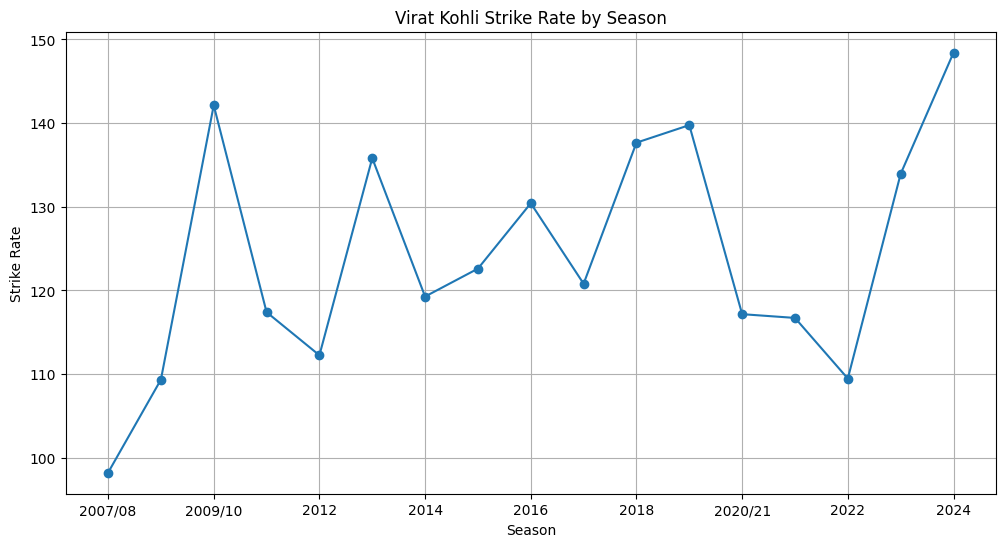

In [224]:
plt.figure(figsize=(12,6))

virat_stats['strike_rate'].plot(
    kind='line',
    marker='o'
)

plt.title("Virat Kohli Strike Rate by Season")

plt.ylabel("Strike Rate")

plt.xlabel("Season")

plt.grid(True)

plt.show()

In [225]:
bowler_stats = deliveries.groupby('bowler').agg({
    'total_runs': 'sum',
    'ball': 'count'
}).reset_index()

In [226]:
bowler_stats.columns = [
    'bowler',
    'runs_conceded',
    'balls'
]

In [227]:
bowler_stats['overs'] = (
    bowler_stats['balls'] / 6
)

In [228]:
bowler_stats['economy'] = (
    bowler_stats['runs_conceded'] /
    bowler_stats['overs']
)

In [229]:
bowler_stats = bowler_stats[
    bowler_stats['balls'] > 500
]

In [230]:
best_economy = bowler_stats.sort_values(
    by='economy'
).head(10)

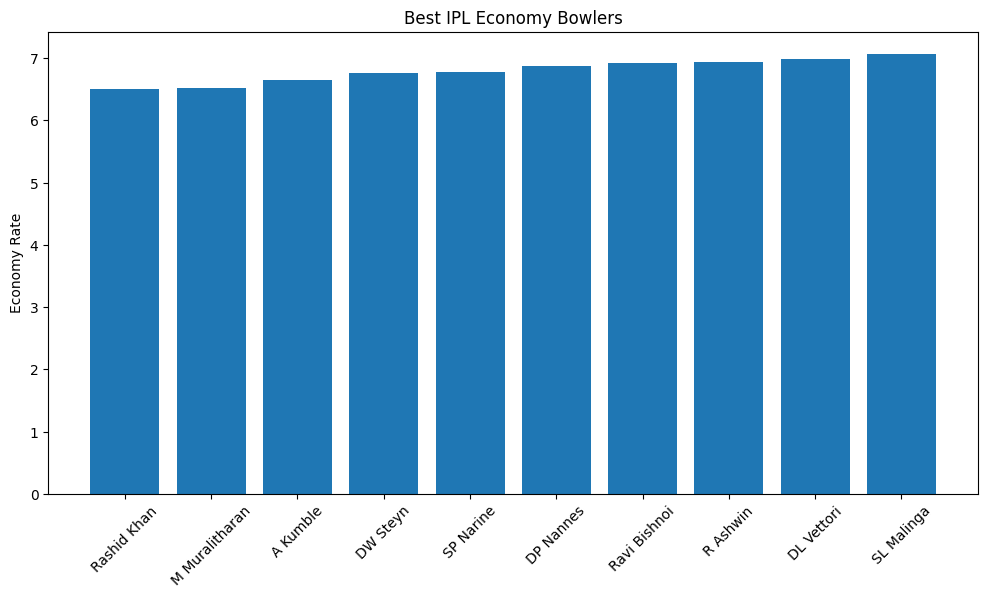

In [231]:
plt.figure(figsize=(12,6))

plt.bar(
    best_economy['bowler'],
    best_economy['economy']
)

plt.xticks(rotation=45)

plt.ylabel("Economy Rate")

plt.title("Best IPL Economy Bowlers")

plt.show()

In [238]:
matches['result_type'] = matches.apply(
    lambda x: 'Chasing Win'
    if x['team2'] == x['winner']
    else 'Defending Win',
    axis=1
)

In [239]:
venue_result = pd.crosstab(
    matches['city'],
    matches['result_type']
)

In [240]:
venue_result_percent = venue_result.div(
    venue_result.sum(axis=1),
    axis=0
) * 100

In [241]:
venue_result_percent.head()

result_type,Chasing Win,Defending Win
city,,
Abu Dhabi,62.162162,37.837838
Ahmedabad,55.000000,45.000000
Bangalore,52.830189,47.169811
Bengaluru,40.000000,60.000000
Bloemfontein,50.000000,50.000000


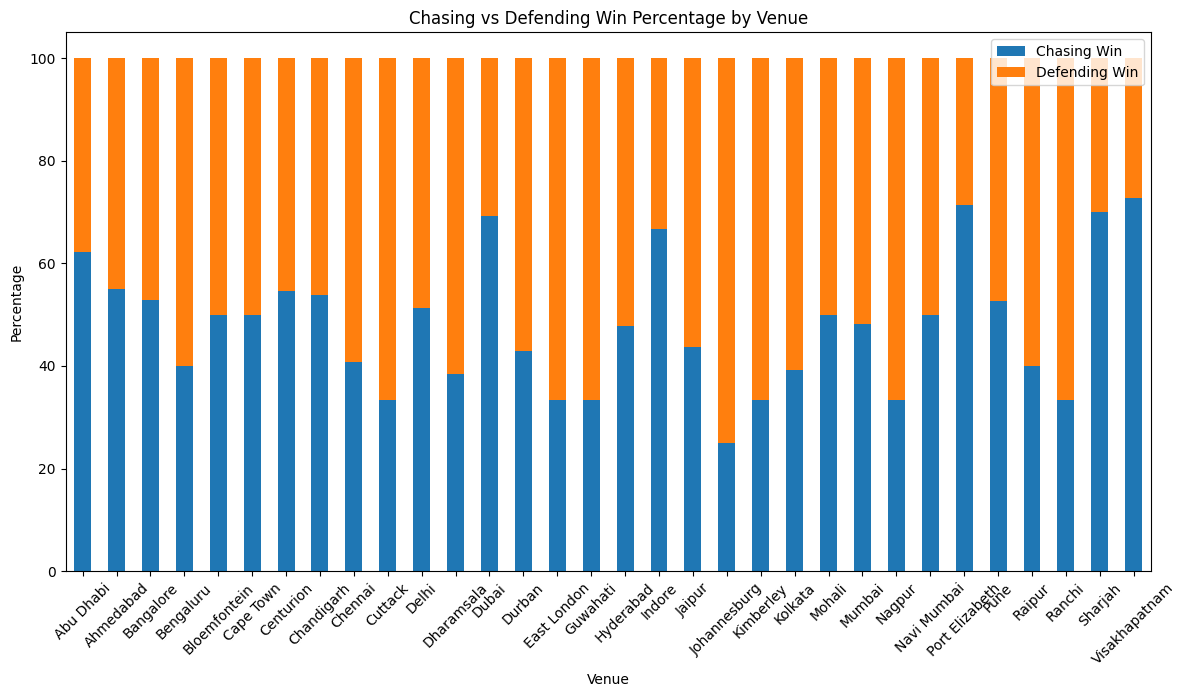

In [242]:
venue_result_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title(
    "Chasing vs Defending Win Percentage by Venue"
)

plt.ylabel("Percentage")

plt.xlabel("Venue")

plt.xticks(rotation=45)

plt.legend(loc='upper right')

plt.show()

In [243]:
log_acc = 0.806844

rf_acc = 0.999164

xgb_acc = 0.945246

In [244]:
batter_stats.to_csv(
    'batter_clusters.csv',
    index=False
)

In [245]:
venue_result_percent.to_csv(
    'venue_analysis.csv'
)

In [246]:
virat_stats.to_csv(
    'virat_stats.csv'
)

In [248]:
bowler_stats.to_csv(
    'bowler_stats.csv',
    index=False
)

In [249]:
!ls

app.py		     cities.pkl      pipe.pkl	  venue_analysis.csv
batter_clusters.csv  deliveries.csv  sample_data  virat_stats.csv
bowler_stats.csv     matches.csv     teams.pkl


In [254]:
%%writefile app.py

import streamlit as st
import pandas as pd
import pickle
import matplotlib.pyplot as plt

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="IPL Sports Analytics Platform",
    page_icon="🏏",
    layout="wide"
)

# =========================================================
# LOAD FILES
# =========================================================

pipe = pickle.load(open('pipe.pkl', 'rb'))

teams = pickle.load(open('teams.pkl', 'rb'))

cities = pickle.load(open('cities.pkl', 'rb'))

matches = pd.read_csv('matches.csv')

deliveries = pd.read_csv('deliveries.csv')

batter_clusters = pd.read_csv('batter_clusters.csv')

venue_analysis = pd.read_csv('venue_analysis.csv')

bowler_stats = pd.read_csv('bowler_stats.csv')

virat_stats = pd.read_csv('virat_stats.csv')

# =========================================================
# MODEL ACCURACIES
# =========================================================

log_acc = 0.806844

rf_acc = 0.999164

xgb_acc = 0.945246

# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.title("🏏 IPL Sports Analytics")

st.sidebar.markdown("""
### Features
- Live Win Predictor
- ML Model Comparison
- Player Analytics
- Bowling Analytics
- KMeans Clustering
- Venue Analytics
- Head-to-Head Comparison
- Season Trends
""")

st.sidebar.write("---")

st.sidebar.info(
    "Built using Python, Machine Learning, "
    "Scikit-learn, XGBoost & Streamlit"
)

# =========================================================
# TITLE
# =========================================================

st.title("🏏 IPL Sports Analytics Platform")

st.markdown(
    "## End-to-End Cricket Analytics & Match Prediction Dashboard"
)

st.write("---")

# =========================================================
# PROJECT OVERVIEW
# =========================================================

st.subheader("📊 Project Overview")

st.markdown("""
This platform analyzes 16+ seasons of IPL cricket data using:

- Logistic Regression
- Random Forest
- XGBoost
- KMeans Clustering

### Features Included:
- Real-time win prediction
- Player performance analytics
- Bowling economy analysis
- Venue-based insights
- Head-to-head team comparison
- Player clustering
- Season-wise trends
""")

st.write("---")

# =========================================================
# KPI SECTION
# =========================================================

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Total Matches",
        matches.shape[0]
    )

with col2:
    st.metric(
        "Teams",
        len(teams)
    )

with col3:
    st.metric(
        "Cities",
        len(cities)
    )

with col4:
    st.metric(
        "Best Model Accuracy",
        "80.68%"
    )

st.write("---")

# =========================================================
# TABS
# =========================================================

tab1, tab2, tab3, tab4, tab5, tab6, tab7, tab8 = st.tabs([
    "🏏 Live Predictor",
    "🤖 ML Models",
    "🏆 Player Analytics",
    "🎯 Bowling Analytics",
    "🧠 KMeans Clustering",
    "🏟 Venue Analytics",
    "⚔ Head-to-Head",
    "📈 Season Trends"
])

# =========================================================
# TAB 1 — LIVE PREDICTOR
# =========================================================

with tab1:

    st.header("Live IPL Win Predictor")

    colA, colB, colC = st.columns(3)

    with colA:

        batting_team = st.selectbox(
            'Select Batting Team',
            sorted(teams)
        )

    available_bowling_teams = [
        team for team in teams
        if team != batting_team
    ]

    with colB:

        bowling_team = st.selectbox(
            'Select Bowling Team',
            sorted(available_bowling_teams)
        )

    with colC:

        city = st.selectbox(
            'Select Match City',
            sorted(cities)
        )

    st.write("---")

    colD, colE = st.columns(2)

    with colD:

        target = st.number_input(
            'Target Score',
            min_value=1,
            value=180
        )

    with colE:

        score = st.number_input(
            'Current Score',
            min_value=0,
            value=50
        )

    colF, colG = st.columns(2)

    with colF:

        overs = st.number_input(
            'Overs Completed',
            min_value=0.1,
            max_value=20.0,
            value=5.0,
            step=0.1
        )

    with colG:

        wickets = st.number_input(
            'Wickets Lost',
            min_value=0,
            max_value=10,
            value=2
        )

    if st.button('Predict Probability'):

        runs_left = target - score

        balls_left = int(120 - (overs * 6))

        wickets_left = 10 - wickets

        crr = score / overs if overs > 0 else 0

        rrr = (
            (runs_left * 6) / balls_left
            if balls_left > 0 else 0
        )

        input_df = pd.DataFrame({
            'batting_team': [batting_team],
            'bowling_team': [bowling_team],
            'city': [city],
            'runs_left': [runs_left],
            'balls_left': [balls_left],
            'wickets_left': [wickets_left],
            'total_runs_x': [target],
            'crr': [crr],
            'rrr': [rrr]
        })

        result = pipe.predict_proba(input_df)

        loss = result[0][0]

        win = result[0][1]

        st.info(
            f"{batting_team} need "
            f"{runs_left} runs in "
            f"{balls_left} balls with "
            f"{wickets_left} wickets remaining."
        )

        colH, colI = st.columns(2)

        with colH:

            st.metric(
                label=f"{batting_team} Win %",
                value=f"{round(win * 100)}%"
            )

        with colI:

            st.metric(
                label=f"{bowling_team} Win %",
                value=f"{round(loss * 100)}%"
            )

        st.progress(int(win * 100))

        prob_df = pd.DataFrame({
            'Team': [batting_team, bowling_team],
            'Probability': [win * 100, loss * 100]
        })

        st.bar_chart(
            prob_df.set_index('Team')
        )

# =========================================================
# TAB 2 — ML MODELS
# =========================================================

with tab2:

    st.header("Machine Learning Model Comparison")

    comparison_df = pd.DataFrame({
        'Model': [
            'Logistic Regression',
            'Random Forest',
            'XGBoost'
        ],
        'Accuracy': [
            log_acc,
            rf_acc,
            xgb_acc
        ]
    })

    st.table(comparison_df)

    fig, ax = plt.subplots(figsize=(8,5))

    ax.bar(
        comparison_df['Model'],
        comparison_df['Accuracy']
    )

    ax.set_ylim(0.7, 1.0)

    ax.set_ylabel("Accuracy")

    ax.set_title("ML Model Accuracy Comparison")

    st.pyplot(fig)

    st.markdown("""
    ### Model Insights

    - Logistic Regression provides the most realistic generalized predictions.
    - Random Forest captures complex patterns but shows overfitting.
    - XGBoost performs strongly but also exhibits slight overfitting due to sequential ball-level similarity.
    """)

# =========================================================
# TAB 3 — PLAYER ANALYTICS
# =========================================================

with tab3:

    st.header("Top IPL Run Scorers")

    top_batsmen = deliveries.groupby(
        'batter'
    )['batsman_runs'].sum().sort_values(
        ascending=False
    ).head(10)

    fig, ax = plt.subplots(figsize=(10,5))

    top_batsmen.plot(
        kind='bar',
        ax=ax
    )

    ax.set_ylabel("Runs")

    ax.set_title("Top IPL Run Scorers")

    st.pyplot(fig)

# =========================================================
# TAB 4 — BOWLING ANALYTICS
# =========================================================

with tab4:

    st.header("Best IPL Economy Bowlers")

    best_economy = bowler_stats.sort_values(
        by='economy'
    ).head(10)

    fig, ax = plt.subplots(figsize=(10,5))

    ax.bar(
        best_economy['bowler'],
        best_economy['economy']
    )

    plt.xticks(rotation=45)

    ax.set_ylabel("Economy")

    ax.set_title("Top Economy Bowlers")

    st.pyplot(fig)

# =========================================================
# TAB 5 — KMEANS CLUSTERING
# =========================================================

with tab5:

    st.header("IPL Batter Clustering")

    fig, ax = plt.subplots(figsize=(10,6))

    scatter = ax.scatter(
        batter_clusters['runs'],
        batter_clusters['strike_rate'],
        c=batter_clusters['cluster']
    )

    ax.set_xlabel("Runs")

    ax.set_ylabel("Strike Rate")

    ax.set_title("KMeans Player Segmentation")

    st.pyplot(fig)

    st.info("""
    Clusters identify:
    - Power Hitters
    - Anchors
    - Finishers
    - Low-impact Batters
    """)

# =========================================================
# TAB 6 — VENUE ANALYTICS
# =========================================================

with tab6:

    st.header("Venue Chase vs Defend Analysis")

    venue_analysis = venue_analysis.set_index(
        venue_analysis.columns[0]
    )

    fig, ax = plt.subplots(figsize=(14,7))

    venue_analysis.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    ax.set_ylabel("Percentage")

    ax.set_title(
        "Chasing vs Defending Win Percentage by Venue"
    )

    plt.xticks(rotation=45)

    st.pyplot(fig)

# =========================================================
# TAB 7 — HEAD TO HEAD
# =========================================================

with tab7:

    st.header("Head-to-Head Team Comparison")

    colX, colY = st.columns(2)

    with colX:

        team1 = st.selectbox(
            "Select Team 1",
            sorted(teams),
            key='team1'
        )

    available_team2 = [
        t for t in teams
        if t != team1
    ]

    with colY:

        team2 = st.selectbox(
            "Select Team 2",
            sorted(available_team2),
            key='team2'
        )

    h2h = matches[
        (
            (matches['team1'] == team1) &
            (matches['team2'] == team2)
        ) |
        (
            (matches['team1'] == team2) &
            (matches['team2'] == team1)
        )
    ]

    st.write(f"### Total Matches: {h2h.shape[0]}")

    winner_counts = h2h['winner'].value_counts()

    st.table(winner_counts)

    fig, ax = plt.subplots(figsize=(8,5))

    winner_counts.plot(
        kind='bar',
        ax=ax
    )

    ax.set_ylabel("Wins")

    ax.set_title(
        f"{team1} vs {team2}"
    )

    st.pyplot(fig)

# =========================================================
# TAB 8 — SEASON TRENDS
# =========================================================

with tab8:

    st.header("Virat Kohli Strike Rate Trend")

    fig, ax = plt.subplots(figsize=(12,5))

    virat_stats['strike_rate'].plot(
        kind='line',
        marker='o',
        ax=ax
    )

    ax.set_ylabel("Strike Rate")

    ax.set_xlabel("Season")

    ax.set_title("Virat Kohli Strike Rate by Season")

    st.pyplot(fig)

    st.info(
        "This visualization highlights player evolution "
        "and batting adaptation across IPL seasons."
    )

# =========================================================
# FOOTER
# =========================================================

st.write("---")

st.caption(
    "Built using Python, Streamlit, "
    "Scikit-learn, XGBoost & IPL Datasets"
)

Overwriting app.py


In [251]:
!pkill -f streamlit

In [255]:
from pyngrok import ngrok
print(ngrok.connect(8501))

NgrokTunnel: "https://6b7d-34-73-166-0.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
!streamlit run app.py &



2026-05-06 08:02:40.645 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.73.166.0:8501

